# Analysis of Records and their rvk Classification and gnd Genre Classification

## Get and Format Data

In [21]:
import numpy as np
import pandas as pd
import pymarc as pm
import os
import plotly.express as px
import utils
import xmltodict
import xml.etree.ElementTree as ET
import utils
import matplotlib.pyplot as plt

In [2]:
# get records which have both rvk Classification and gnd Genre entry
df_remove_na = pd.read_csv('data/converted_data/b3_not_na', sep=';')

In [3]:
# get rvk codes and descriptions
data = []
start_level = 0
i = 0
# make descriptions nested has 19 children max
descriptions = ['' for _ in range(19)]
with open("data/FachA-Z_2023_2.csv", "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        # count indentation level
        level = line.count('|') - 1
        # remove pipes and split on '|'
        parts = [x.strip() for x in line.split('|') if x.strip()]
        if parts and len(parts) > 1:
            if start_level == level:
                start_level += 1
                descriptions[level] = parts[0] + ': ' + parts[1]
            else:
                start_level = level + 1
                descriptions[level] = parts[0] + ': ' + parts[1]
                descriptions[(level - 18):] = [''] * -(level - 18)
            res = dict(zip(range(19), descriptions))
            res["Code"] = parts[0]
            data.append(res)

df_rvk = pd.DataFrame(data)
#df_rvk  = df_rvk[df_rvk['Description'].notna()]

In [4]:
# split on rvk classification and explode dataframe onto rvk Classification number, since a record can have multiple rvk Classification numbers
df_remove_na = df_remove_na.drop('Unnamed: 0', axis=1)
df_remove_na['rvk Classification'] = df_remove_na['rvk Classification'].str.split(',')
df_exploded = df_remove_na.explode('rvk Classification', ignore_index=True)
df_exploded.head(30)

,ISBN,Language Code,Author,Title,Title Statement,Place,Publisher,Date,Number of Pages,Content Type,rvk Classification,gnd Topical Term,gnd Genre
0,3463008386,ger,"Kunze, Michael",NaN,Straße ins Feuer vom Leben und Sterben in der ...,München,Kindler,1982,397 S.,txt,GN 9999,"Strafrecht, Hexenprozess",Fiktionale Darstellung
1,3463008386,ger,"Kunze, Michael",NaN,Straße ins Feuer vom Leben und Sterben in der ...,München,Kindler,1982,397 S.,txt,LC 41005,"Strafrecht, Hexenprozess",Fiktionale Darstellung
2,3463008386,ger,"Kunze, Michael",NaN,Straße ins Feuer vom Leben und Sterben in der ...,München,Kindler,1982,397 S.,txt,NS 4470,"Strafrecht, Hexenprozess",Fiktionale Darstellung
3,NaN,ger,"Leppmann, Wolfgang",NaN,Goethe und die Deutschen d. Nachruhm e. Dichte...,Bern ; München,Scherz,1982,318 S.,txt,GK 4291,Rezeption,Biografie
4,NaN,ger,"Leppmann, Wolfgang",NaN,Goethe und die Deutschen d. Nachruhm e. Dichte...,Bern ; München,Scherz,1982,318 S.,txt,GK 4351,Rezeption,Biografie
5,3515035400,ger,"Dorsch, Volker",NaN,Die Handelskammern der Rheinprovinz in der z...,Wiesbaden,Steiner,1982,"IX, 199 S.",txt,NR 3450,Handelskammer,Hochschulschrift
6,3515035400,ger,"Dorsch, Volker",NaN,Die Handelskammern der Rheinprovinz in der z...,Wiesbaden,Steiner,1982,"IX, 199 S.",txt,NW 3150,Handelskammer,Hochschulschrift
7,3880731160,ger,"Volz, Ruprecht",NaN,Strindbergs Wanderungsdramen Studien zur Episi...,München,Tuduv-Verl.-Ges.,1982,187 S.,txt,GX 7283,Stationendrama,Hochschulschrift
8,3920190262,ger,NaN,NaN,Verhaltenstherapie in der Suchtkrankenhilfe Vo...,München,Röttger,1982,"V, 199 S.",txt,CU 8500,"Sozialtherapie, Sucht, Verhaltenstherapie, Suc...",Konferenzschrift
9,3820462503,ger,"Lyon, Regine",NaN,"Zolas ""foi nouvelle"" zum faschistischen Syndro...",Frankfurt am Main [u.a.],Lang,(1982),252 S.,txt,IG 7655,"Ideologie, Faschismus","Hochschulschrift, Paris <Werktitel>"


In [5]:
# convert rvk into description add to exploded df
rvk_description = []
# rvk description is nested up to 19 layers deep
for i in range(19):
    rvk_description = []
    code_dict = dict(zip(df_rvk['Code'], df_rvk[i], ))
    for classification in df_exploded['rvk Classification']:
        temp = code_dict.get(classification)
        rvk_description.append(temp)
    df_exploded[i] = rvk_description

In [6]:
# show dataframe
df_exploded.head(20)

,ISBN,Language Code,Author,Title,Title Statement,Place,Publisher,Date,Number of Pages,Content Type,...,9,10,11,12,13,14,15,16,17,18
0,3463008386,ger,"Kunze, Michael",NaN,Straße ins Feuer vom Leben und Sterben in der ...,München,Kindler,1982,397 S.,txt,...,,,,,,,,,,
1,3463008386,ger,"Kunze, Michael",NaN,Straße ins Feuer vom Leben und Sterben in der ...,München,Kindler,1982,397 S.,txt,...,None,None,None,None,None,None,None,None,None,None
2,3463008386,ger,"Kunze, Michael",NaN,Straße ins Feuer vom Leben und Sterben in der ...,München,Kindler,1982,397 S.,txt,...,None,None,None,None,None,None,None,None,None,None
3,NaN,ger,"Leppmann, Wolfgang",NaN,Goethe und die Deutschen d. Nachruhm e. Dichte...,Bern ; München,Scherz,1982,318 S.,txt,...,GK 4200 - GK 4431: Geistige Welt,"GK 4290: Wirkung auf Zeitgenossen, Umwelt und ...",GK 4291: Zeitgenossen,,,,,,,
4,NaN,ger,"Leppmann, Wolfgang",NaN,Goethe und die Deutschen d. Nachruhm e. Dichte...,Bern ; München,Scherz,1982,318 S.,txt,...,None,None,None,None,None,None,None,None,None,None
5,3515035400,ger,"Dorsch, Volker",NaN,Die Handelskammern der Rheinprovinz in der z...,Wiesbaden,Steiner,1982,"IX, 199 S.",txt,...,,,,,,,,,,
6,3515035400,ger,"Dorsch, Volker",NaN,Die Handelskammern der Rheinprovinz in der z...,Wiesbaden,Steiner,1982,"IX, 199 S.",txt,...,None,None,None,None,None,None,None,None,None,None
7,3880731160,ger,"Volz, Ruprecht",NaN,Strindbergs Wanderungsdramen Studien zur Episi...,München,Tuduv-Verl.-Ges.,1982,187 S.,txt,...,,,,,,,,,,
8,3920190262,ger,NaN,NaN,Verhaltenstherapie in der Suchtkrankenhilfe Vo...,München,Röttger,1982,"V, 199 S.",txt,...,,,,,,,,,,
9,3820462503,ger,"Lyon, Regine",NaN,"Zolas ""foi nouvelle"" zum faschistischen Syndro...",Frankfurt am Main [u.a.],Lang,(1982),252 S.,txt,...,,,,,,,,,,


In [7]:
# get all records, where gnd Genre classifies as fictional
df_fiktion = df_exploded[df_exploded['gnd Genre'] == 'Fiktionale Darstellung']

## Plots

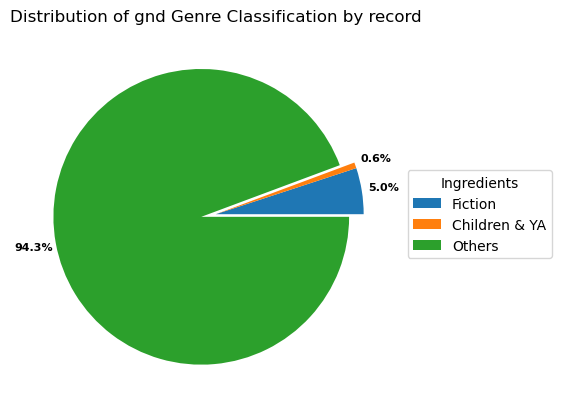

In [83]:
# plots pie chart of percentage of records labeled as "Fiktionale Darstellung", "Jugendbuch" or "Kinderbuch" or other categories by gnd Genre
x = df_remove_na['gnd Genre'].value_counts()

fiktionale_darstellung = x.iloc[3]
kinder_jugendbuch = x.iloc[34] + x.iloc[31]
non_fiction = x.sum() - (kinder_jugendbuch + fiktionale_darstellung)
labels = "Fiction", "Children & YA", "Others"
fig, ax = plt.subplots()
explode = (0, 0, 0.1)
ax.set_title("Distribution of gnd Genre Classification by record")
wedges, texts, autotexts = ax.pie((fiktionale_darstellung, kinder_jugendbuch, non_fiction), explode=explode,  autopct='%1.1f%%', pctdistance=1.15)
ax.legend(wedges, labels,
          title="Ingredients",
          loc="center left",
          bbox_to_anchor=(1, 0, 0.5, 1))
plt.setp(autotexts, size=8, weight="bold")
plt.show()

In [85]:
# searches for match in all 18 nested rvk classifications in dataframe and returns them
def search_keyword(keyword, df, case):
    df = df.fillna('')
    mask = df[0].str.contains(keyword, case=case)
    for i in range(1, 19):
        mask += df[i].str.contains(keyword, case=case)
    res = df[mask]
    df
    return res

In [92]:
type(search_keyword('Einzelne Autoren', df_fiktion, False)['Title Statement'].unique())

numpy.ndarray

In [39]:
def plot_treemap(df, level):
    # creates treemap given dataframe, level should be range on how deep the treemap goes
    fig = px.treemap(df, path=([i for i in level]))
    fig.update_traces(root_color="lightgrey")
    fig.update_layout(margin = dict(t=50, l=25, r=25, b=25))
    fig.show()

In [41]:
# Treemap for works of fiktion which are classified as german literature
df_treemap= df_fiktion[df_fiktion[0].notna()]
df_treemap = df_fiktion[df_fiktion[1] == 'GE 3003 - GT 1500: Deutsche Literatur']
plot_treemap(df_treemap, range(1, 10))